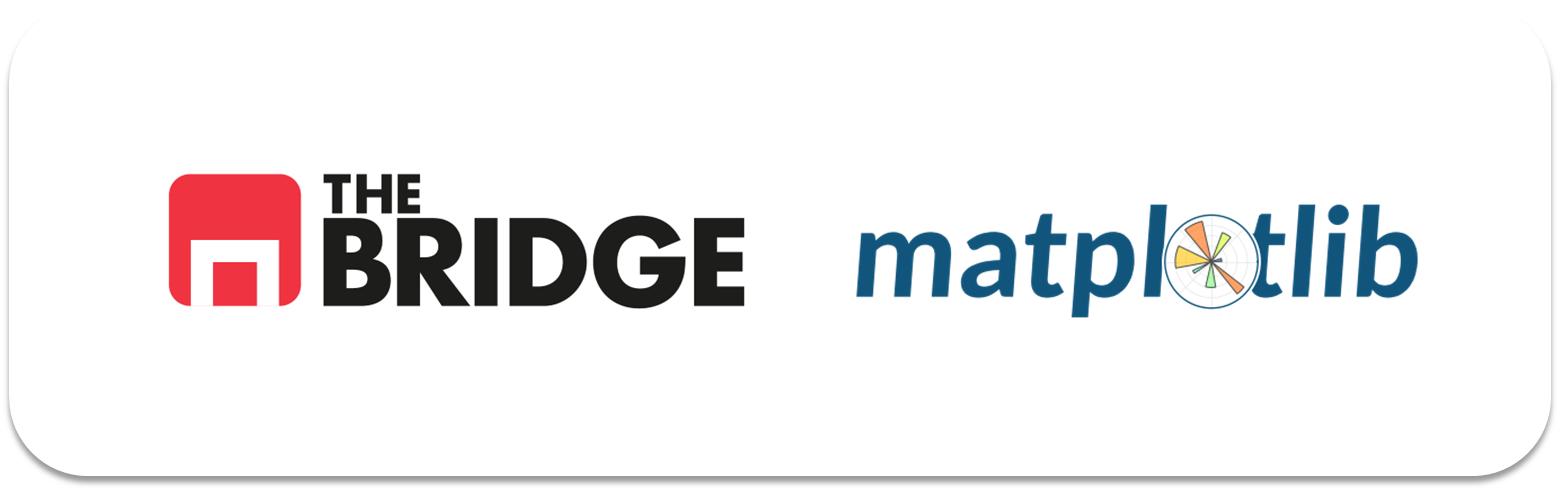

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [8]:
df = pd.read_csv("./data/california_cities.csv", index_col =0)
df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [9]:
df.isna().sum().sort_values(ascending = False)

elevation_m           48
elevation_ft          12
area_water_percent     5
area_total_km2         5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

In [12]:
df["elevation_m"].isna()

0      False
1      False
2       True
3       True
4      False
       ...  
477    False
478    False
479    False
480    False
481    False
Name: elevation_m, Length: 482, dtype: bool

In [14]:
df["elevation_m_from_ft"]=(df["elevation_ft"]* 0.3048).round(1)

In [16]:
df.loc[df["elevation_m"].isna()]

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent,elevation_m_from_ft
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79,10.1
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28,13.1
15,Arcata,40.866389,-124.082778,NaN,23.0,17231,10.994,9.097,1.897,28.473,23.561,4.912,17.25,7.0
26,Bakersfield,35.366667,-119.016667,NaN,404.0,347483,143.609,142.164,1.445,371.946,368.204,3.742,1.01,123.1
41,Bishop,37.363500,-118.395100,NaN,4150.0,3879,1.911,1.864,0.047,4.949,4.827,0.122,2.50,1264.9
47,Brentwood,37.931944,-121.695833,NaN,79.0,51481,14.805,14.786,0.019,38.345,38.295,0.049,0.13,24.1
54,Calexico,32.678889,-115.498889,NaN,3.0,38572,8.391,8.391,0.000,21.733,21.733,0.000,0.00,0.9
57,Calipatria,33.125556,-115.514167,NaN,-180.0,7705,3.716,3.716,0.000,9.624,9.624,0.000,0.00,-54.9
64,CarmelbytheSea,36.555278,-121.923333,NaN,NaN,3722,1.080,1.080,0.000,2.798,2.798,0.000,0.00,NaN
76,Claremont,34.110000,-117.719722,NaN,NaN,34926,13.486,13.348,0.138,34.930,34.571,0.358,1.03,NaN


In [13]:
df.loc[df["elevation_m"].isna(), ["city", "elevation_m", "elevation_ft"]]

,city,elevation_m,elevation_ft
2,Alameda,NaN,33.0
3,Albany,NaN,43.0
15,Arcata,NaN,23.0
26,Bakersfield,NaN,404.0
41,Bishop,NaN,4150.0
47,Brentwood,NaN,79.0
54,Calexico,NaN,3.0
57,Calipatria,NaN,-180.0
64,CarmelbytheSea,NaN,NaN
76,Claremont,NaN,NaN


In [18]:
df = df.dropna()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 427 non-null    object 
 1   latd                 427 non-null    float64
 2   longd                427 non-null    float64
 3   elevation_m          427 non-null    float64
 4   elevation_ft         427 non-null    float64
 5   population_total     427 non-null    int64  
 6   area_total_sq_mi     427 non-null    float64
 7   area_land_sq_mi      427 non-null    float64
 8   area_water_sq_mi     427 non-null    float64
 9   area_total_km2       427 non-null    float64
 10  area_land_km2        427 non-null    float64
 11  area_water_km2       427 non-null    float64
 12  area_water_percent   427 non-null    float64
 13  elevation_m_from_ft  427 non-null    float64
dtypes: float64(12), int64(1), object(1)
memory usage: 50.0+ KB


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

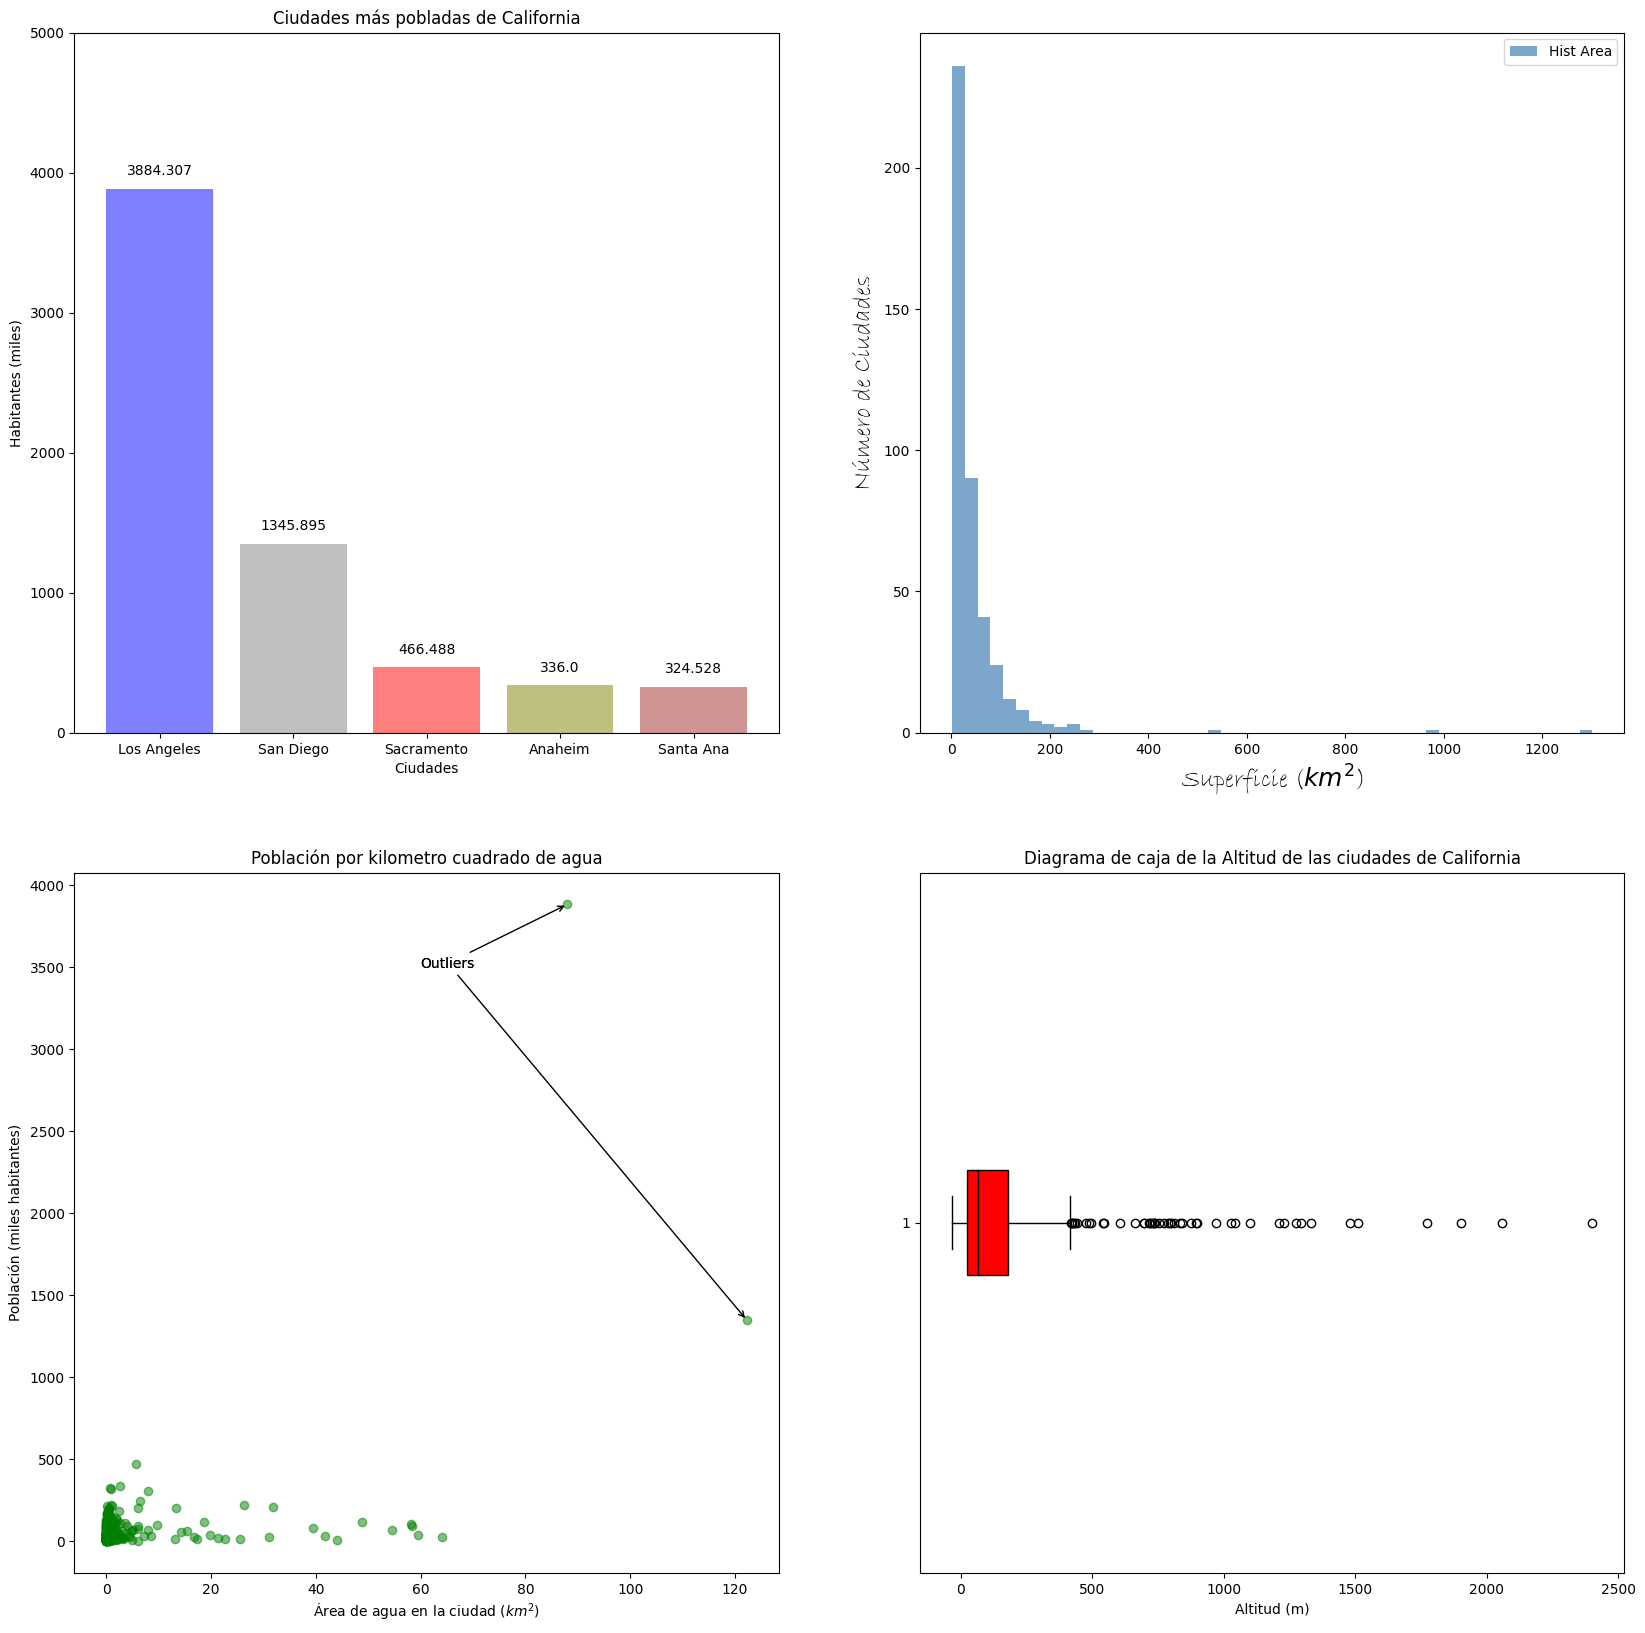

In [25]:
ciudades_mas_pobladas = df.loc[df.population_total.nlargest(5).index, ["city","population_total"]]
ciudades_mas_pobladas

,city,population_total
239,LosAngeles,3884307
367,SanDiego,1345895
359,Sacramento,466488
9,Anaheim,336000
386,SantaAna,324528


<Axes: >

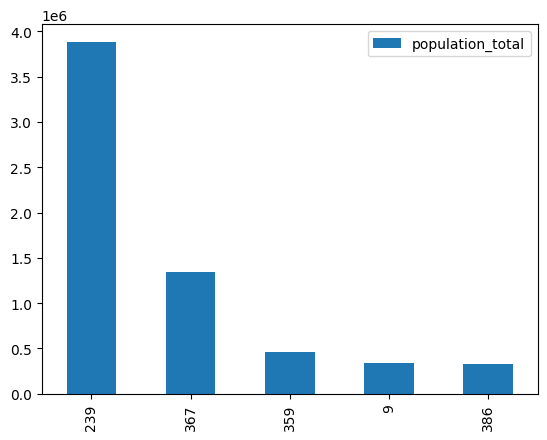

In [29]:
ciudades_mas_pobladas.plot(kind = "bar")

In [40]:
list(enumerate(df.loc[df.population_total.nlargest(5).index,["city","population_total"]].set_index("city")))

[(0, 'population_total')]

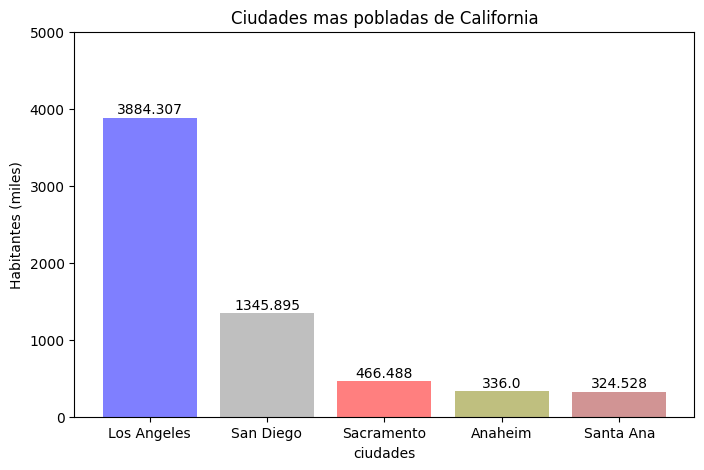

In [41]:
#preguntaa 1
def separa_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo += " "
        nuevo += letra
    return nuevo

ciudades_mas_pobladas = df.loc[df.population_total.nlargest(5).index,["city","population_total"]]
ciudades = [separa_nombre(ciudad)for ciudad in ciudades_mas_pobladas["city"].to_list()]

colores = ["blue", "gray", "red", "olive", "brown"]


plt.figure(figsize = (8,5))

plt.bar(x = ciudades,
        height = ciudades_mas_pobladas["population_total"]/1000,
        color = colores,
        alpha= 0.5)

plt.ylim([0,5000])
plt.ylabel("Habitantes (miles)")
plt.xlabel("ciudades")
plt.title("Ciudades mas pobladas de California")

ciudades_mas_pobladas.set_index("city", inplace = True)

for indice, ciudad in enumerate(ciudades_mas_pobladas.index):
    poblacion = ciudades_mas_pobladas.loc[ciudad, "population_total"]/1000
    plt.text(ciudades[indice], poblacion + 50, f"{poblacion}", ha = "center")



plt.show()


In [43]:
# pregunta 2
import matplotlib

print(matplotlib.font_manager.findfont('Bradley Hand ITC'))

C:\Windows\Fonts\BRADHITC.TTF


In [44]:
dict(family = "Bradley Hand ITC", size = 18)

{'family': 'Bradley Hand ITC', 'size': 18}

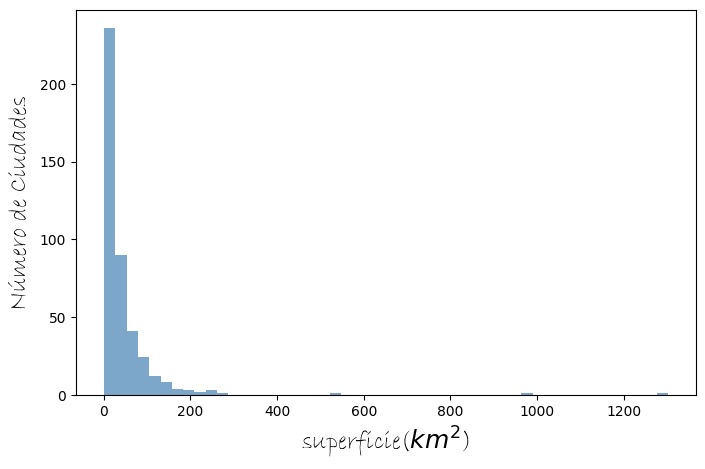

In [48]:
plt.figure(figsize = (8,5))

plt.hist(df["area_total_km2"],
         color = "steelblue",
         alpha = 0.7,
         bins = 50,
         label ="Hist Area")

plt.xlabel("superficie($km^2$)", fontdict = dict(family = "Bradley Hand ITC", size = 18))
plt.ylabel("Número de Ciudades", fontdict = dict(family = "Bradley Hand ITC", size = 18))






plt.show()

In [55]:
ciudades_mas_pobladas.population_total.nlargest(2)

city
LosAngeles    3884307
SanDiego      1345895
Name: population_total, dtype: int64

In [56]:
ciudades_mas_pobladas.population_total.nlargest(2).iloc[0]

np.int64(3884307)

In [ ]:
ciudades_mas_pobladas.population_total.nlargest(2).iloc[1]

np.int64(1345895)

In [67]:
(df["population_total"]/1000).nlargest(2).iloc[0]

np.float64(3884.307)

In [68]:
df.loc[df.population_total == (df["population_total"]).nlargest(2).iloc[0],"area_water_km2"].values[0]

np.float64(88.0)

IndexError: index 0 is out of bounds for axis 0 with size 0

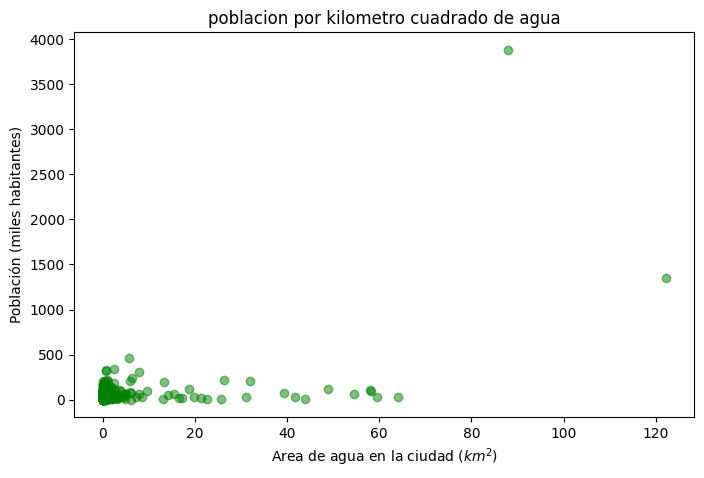

In [72]:
#pregunta 3
plt.figure(figsize = (8,5))

plt.scatter(x = df["area_water_km2"],
            y = df["population_total"]/1000,
            alpha = 0.5,
            color = "green")

plt.xlabel("Area de agua en la ciudad ($km^2$)")
plt.ylabel("Población (miles habitantes)")
plt.title("poblacion por kilometro cuadrado de agua")


outlier_1_y = (df["population_total"]/1000).nlargest(2).iloc[0]
outlier_2_y = (df["population_total"]/1000).nlargest(2).iloc[1]

outlier_1_x = df.loc[df.population_total == outlier_1_y ,"area_water_km2"].values[0]
outlier_2_x = df.loc[df.population_total == outlier_2_y ,"area_water_km2"].values[0]

plt.annotate(xy = ( outlier_1_x,outlier_1_y/1000),
             xytext = (70,3000),
             text = "Outliers")


plt.show()

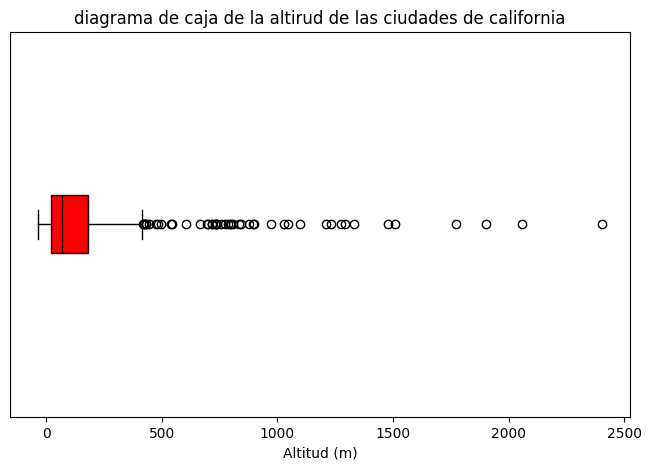

In [82]:
plt.figure(figsize=(8,5))

plt.boxplot(df["elevation_m"],
            vert = False,
            patch_artist= True,
            boxprops=dict(facecolor ="red"),
            medianprops=dict(color = "black"))

plt.xlabel("Altitud (m)")
plt.title("diagrama de caja de la altirud de las ciudades de california")
plt.yticks([])

plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.